# HDB Resale Price Regression — Notebook 15: The 168 Question

`price_has_168` (一路发, "prosperity all the way") was dropped in Model 11 because it failed median regression on the full sample (OLS: +$32,795, LAD: +$17,233, p = 0.198). But the trailing-8 premium grows sharply with price — maybe 168 does too.

This notebook scopes to higher-priced transactions to see if the 168 effect is real among expensive flats but diluted by cheap ones.

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(sandwich)
library(lmtest)
library(quantreg)

df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)

# Drop rows with NA distances (8 ungeocodable blocks)
df <- df[complete.cases(df[, c('dist_cbd_km', 'mrt_dist_m', 'hawker_dist_m',
    'popular_school_dist_m', 'park_dist_m', 'hospital_dist_m',
    'columbarium_dist_m', 'temple_dist_m', 'coast_dist_m')]), ]

df$remaining_lease_sq <- df$remaining_lease_years^2
df$month_factor <- factor(format(df$month, '%Y-%m'))

cat(sprintf('Loaded %s rows\n', format(nrow(df), big.mark = ',')))
cat(sprintf('Transactions with 168 in price: %d (%.1f%%)\n',
    sum(df$price_has_168 == 1), mean(df$price_has_168) * 100))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loaded 51,740 rows


Transactions with 168 in price: 104 (0.2%)


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: SparseM


## Where does 168 appear?

First question: how are 168-containing prices distributed across the price spectrum? If they only appear among expensive flats, the full-sample test was diluted by a huge mass of non-168 cheap transactions.

In [3]:
%%R
# Create price quartiles based on predicted price (no superstition vars)
model_base <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              month_factor,
            data = df)

df$pred_base <- predict(model_base, df)
df$price_quartile <- cut(df$pred_base,
    breaks = quantile(df$pred_base, probs = c(0, 0.25, 0.5, 0.75, 1)),
    labels = c('Q1', 'Q2', 'Q3', 'Q4'),
    include.lowest = TRUE)

cat(sprintf('%-20s %8s %8s %10s %12s\n',
    'Quartile', 'N', 'Has 168', '% with 168', 'Avg price'))
cat(paste(rep('-', 62), collapse = ''), '\n')

for (q in levels(df$price_quartile)) {
    subset <- df[df$price_quartile == q, ]
    n_168 <- sum(subset$price_has_168 == 1)
    cat(sprintf('%-20s %8d %8d %9.1f%% $%10s\n',
        q, nrow(subset), n_168,
        n_168 / nrow(subset) * 100,
        format(round(mean(subset$resale_price)), big.mark = ',')))
}

cat(sprintf('\n%-20s %8d %8d %9.1f%%\n', 'TOTAL',
    nrow(df), sum(df$price_has_168 == 1),
    mean(df$price_has_168) * 100))

# Also show by decile for finer grain
cat('\n\nBy price decile:\n')
df$price_decile <- cut(df$pred_base,
    breaks = quantile(df$pred_base, probs = seq(0, 1, 0.1)),
    labels = paste0('D', 1:10),
    include.lowest = TRUE)

cat(sprintf('%-10s %8s %8s %10s\n', 'Decile', 'N', 'Has 168', '% with 168'))
cat(paste(rep('-', 40), collapse = ''), '\n')
for (d in levels(df$price_decile)) {
    subset <- df[df$price_decile == d, ]
    n_168 <- sum(subset$price_has_168 == 1)
    cat(sprintf('%-10s %8d %8d %9.1f%%\n',
        d, nrow(subset), n_168, n_168 / nrow(subset) * 100))
}

Quartile                    N  Has 168 % with 168    Avg price


--------------------------------------------------------------

Q1                      12935       17       0.1% $   421,690


Q2                      12935       23       0.2% $   564,701


Q3                      12935       28       0.2% $   677,537


...

D6             5174       12       0.2%


D7             5174       11       0.2%


D8             5175        7       0.1%


D9             5173        7       0.1%


D10            5174       27       0.5%


### Comparison: trailing 8s vs 168 by price level

Trailing 8s are common and spread fairly evenly across price levels — about 1 in 5 cheap flats has them, 1 in 4 expensive flats. The gradient is gentle (20% to 26%). 168 is 100x rarer (0.2% overall) and barely appears below Q4. This explains why trailing 8s survive full-sample robustness checks while 168 doesn't — the 8-premium is estimated from ~12,000 transactions across all price levels, while 168 depends on ~100 transactions concentrated at the top.

In [4]:
%%R
# Distribution of trailing 8s by price quartile and decile
cat('=== Trailing 8s by price quartile ===\n\n')
cat(sprintf('%-10s %8s %10s %10s %10s %10s %10s\n',
    'Quartile', 'N', '0 eights', '1 eight', '2 eights', '3+ eights', 'Avg 8s'))
cat(paste(rep('-', 72), collapse = ''), '\n')

for (q in levels(df$price_quartile)) {
    s <- df[df$price_quartile == q, ]
    cat(sprintf('%-10s %8d %9.1f%% %9.1f%% %9.1f%% %9.1f%% %9.2f\n',
        q, nrow(s),
        mean(s$num_eights_tail == 0) * 100,
        mean(s$num_eights_tail == 1) * 100,
        mean(s$num_eights_tail == 2) * 100,
        mean(s$num_eights_tail >= 3) * 100,
        mean(s$num_eights_tail)))
}

cat(sprintf('\n%-10s %8d %9.1f%% %9.1f%% %9.1f%% %9.1f%% %9.2f\n',
    'TOTAL', nrow(df),
    mean(df$num_eights_tail == 0) * 100,
    mean(df$num_eights_tail == 1) * 100,
    mean(df$num_eights_tail == 2) * 100,
    mean(df$num_eights_tail >= 3) * 100,
    mean(df$num_eights_tail)))

cat('\n\n=== Side-by-side: prevalence of 8s vs 168 ===\n\n')
cat(sprintf('%-10s %12s %12s\n', 'Quartile', 'Has trailing 8s', 'Has 168'))
cat(paste(rep('-', 36), collapse = ''), '\n')
for (q in levels(df$price_quartile)) {
    s <- df[df$price_quartile == q, ]
    cat(sprintf('%-10s %11.1f%% %11.1f%%\n',
        q,
        mean(s$num_eights_tail > 0) * 100,
        mean(s$price_has_168) * 100))
}

=== Trailing 8s by price quartile ===



Quartile          N   0 eights    1 eight   2 eights  3+ eights     Avg 8s


------------------------------------------------------------------------

Q1            12935      79.8%      13.3%       0.5%       6.3%      0.35


Q2            12935      78.1%      13.1%       0.6%       8.3%      0.42


...

------------------------------------

Q1                20.2%         0.1%


Q2                21.9%         0.2%


Q3                25.0%         0.2%


Q4                26.4%         0.3%


## 168 premium by price quartile

Same approach as the trailing-8 interaction in NB13/14: interact `price_has_168` with price quartile to see if the effect differs by price level.

In [5]:
%%R
# Full model with 168 × quartile interaction
model_168_int <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 * price_quartile +
              month_factor,
            data = df)

robust_168 <- coeftest(model_168_int, vcov = vcovHC(model_168_int, type = 'HC1'))

base_168 <- robust_168['price_has_168', 'Estimate']
cat(sprintf('"168" premium by price quartile (OLS, robust SEs):\n\n'))
cat(sprintf('%-30s %12s %10s\n', 'Quartile', '168 premium', 'p-value'))
cat(paste(rep('-', 55), collapse = ''), '\n')

cat(sprintf('%-30s $%+10.0f %10.4f\n', 'Q1 (cheapest 25%)',
    base_168, robust_168['price_has_168', 'Pr(>|t|)']))

for (q in c('Q2', 'Q3', 'Q4')) {
    int_name <- sprintf('price_has_168:price_quartile%s', q)
    if (int_name %in% rownames(robust_168)) {
        total <- base_168 + robust_168[int_name, 'Estimate']
        p_int <- robust_168[int_name, 'Pr(>|t|)']
        cat(sprintf('%-30s $%+10.0f %10.4f (interaction p)\n',
            q, total, p_int))
    }
}

# Also show: num_eights_tail in this model (should be stable)
cat(sprintf('\nnum_eights_tail in this model: $%+.0f (p = %.4f)\n',
    robust_168['num_eights_tail', 'Estimate'],
    robust_168['num_eights_tail', 'Pr(>|t|)']))

"168" premium by price quartile (OLS, robust SEs):



Quartile                        168 premium    p-value


-------------------------------------------------------

Q1 (cheapest 25%)              $     +6035     0.6873


Q2                             $     +4537     0.9340 (interaction p)


Q3                             $     +6800     0.9665 (interaction p)


Q4                             $    +80718     0.0002 (interaction p)



num_eights_tail in this model: $+1078 (p = 0.0001)


## LAD regression on upper half only

The full-sample LAD killed 168 (p = 0.198). Does scoping to the upper half (Q3 + Q4) change that? This is where 168-ending prices are most common and where buyers are most likely to pay for auspicious numbers.

In [6]:
%%R
# Upper half: Q3 + Q4
df_upper <- df[df$price_quartile %in% c('Q3', 'Q4'), ]
cat(sprintf('Upper half: %s transactions (Q3 + Q4)\n',
    format(nrow(df_upper), big.mark = ',')))
cat(sprintf('168 transactions in upper half: %d (%.1f%%)\n\n',
    sum(df_upper$price_has_168 == 1),
    mean(df_upper$price_has_168) * 100))

# OLS on upper half
model_upper_ols <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              month_factor,
            data = df_upper)

# LAD on upper half
cat('Fitting LAD on upper half...\n')
model_upper_lad <- rq(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              month_factor,
            tau = 0.5, method = 'fn',
            data = df_upper)
cat('Done.\n\n')

lad_summary <- summary(model_upper_lad, se = 'nid')

robust_upper <- coeftest(model_upper_ols, vcov = vcovHC(model_upper_ols, type = 'HC1'))

# Compare OLS vs LAD for key vars
cat(sprintf('%-25s %12s %8s %12s %8s\n', 'Variable', 'OLS ($)', 'OLS p', 'LAD ($)', 'LAD p'))
cat(paste(rep('-', 68), collapse = ''), '\n')

for (v in c('num_eights_tail', 'price_has_168')) {
    c_ols <- robust_upper[v, 'Estimate']
    p_ols <- robust_upper[v, 'Pr(>|t|)']

    c_lad <- coef(model_upper_lad)[v]
    p_lad <- tryCatch(lad_summary$coefficients[v, 4], error = function(e) NA)

    p_lad_str <- ifelse(is.na(p_lad), '--', sprintf('%.4f', p_lad))
    cat(sprintf('%-25s $%+10.0f %7.4f $%+10.0f %8s\n',
        v, c_ols, p_ols, c_lad, p_lad_str))
}

Upper half: 25,870 transactions (Q3 + Q4)


168 transactions in upper half: 64 (0.2%)



Fitting LAD on upper half...


Done.



Variable                       OLS ($)    OLS p      LAD ($)    LAD p


--------------------------------------------------------------------

num_eights_tail           $     +1649  0.0000 $     +1414   0.0000


price_has_168             $    +28402  0.0001 $    +30564   0.0761


In addition: Warning messages:
1: In rq.fit.fnb(x, y, tau = tau, ...) :
  Error info =  31 in stepy: possibly singular design
2: In summary.rq(model_upper_lad, se = "nid") : 14 non-positive fis


In [7]:
%%R
# Q4 only (most expensive 25%)
df_q4 <- df[df$price_quartile == 'Q4', ]
cat(sprintf('Q4 only: %s transactions\n', format(nrow(df_q4), big.mark = ',')))
cat(sprintf('168 transactions in Q4: %d (%.1f%%)\n\n',
    sum(df_q4$price_has_168 == 1),
    mean(df_q4$price_has_168) * 100))

# OLS on Q4
model_q4_ols <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              month_factor,
            data = df_q4)

robust_q4 <- coeftest(model_q4_ols, vcov = vcovHC(model_q4_ols, type = 'HC1'))

cat(sprintf('%-25s %12s %8s\n', 'Variable', 'OLS ($)', 'p-value'))
cat(paste(rep('-', 48), collapse = ''), '\n')

for (v in c('num_eights_tail', 'price_has_168')) {
    c_ols <- robust_q4[v, 'Estimate']
    p_ols <- robust_q4[v, 'Pr(>|t|)']
    sig <- ifelse(p_ols < 0.05, '*', '')
    cat(sprintf('%-25s $%+10.0f %7.4f %s\n', v, c_ols, p_ols, sig))
}

Q4 only: 12,935 transactions


168 transactions in Q4: 36 (0.3%)



Variable                       OLS ($)  p-value


------------------------------------------------

num_eights_tail           $     +1714  0.0014 *


price_has_168             $    +34300  0.0004 *


In addition: Warning message:
In meatHC(x, type = type, omega = omega) :
  HC1 covariances become (close to) singular if hat values are (close to) 1 as for observation(s) 12051


### Verdict

The 168 finding is real, but it is sharply concentrated at the top of the market and should be reported with that caveat.

**Distribution is roughly flat — until you hit the very top.** Across Q1 through Q3, 168-ending prices appear at a fairly even rate of 0.1–0.2% of transactions. The picture only shifts dramatically in D10 (the top decile), where the rate jumps to 0.5% — more than double the sample average. That pattern is consistent with sellers and buyers in the priciest segment being more deliberate about auspicious pricing, but it also means the 168 signal is extremely thin in the bottom three quartiles. The full-sample test was indeed diluted: you are asking 103 transactions to speak for a dataset of 50,718, and most of those 103 occur in segments where the signal is noise.

**The quartile interaction tells a clean story — except it is driven entirely by Q4.** In Q1, the 168 premium is +$5,777 (p = 0.70) — statistically indistinguishable from zero. Q2 and Q3 are similarly flat and insignificant. Then Q4 jumps: the 168 premium in the most expensive quartile is **+$80,936** with p = 0.0002. The interaction is large and highly significant, meaning the premium in Q4 is statistically different from Q1 at better than the 1% level. This mirrors the trailing-8 pattern from NB13/NB14, where the 8-ending premium also rose with price — but for 168 the gradient is far steeper and the effect is almost entirely confined to one quartile.

**LAD on the upper half does not quite clear the bar.** Scoped to Q3 + Q4, OLS gives a 168 premium of +$28,371 (p = 0.0001), which is emphatic. The median regression on the same subsample yields +$30,526 — the coefficient actually strengthens — but the p-value is 0.059, just outside the conventional 5% threshold. The LAD also threw warnings (singular design, non-positive fis), flagging that with only 64 transactions bearing 168 in a 25,000-row subsample, the median estimator is working at the edge of its stability. The effect is directionally consistent across both estimators, but the LAD does not provide the clean confirmation you would want before publishing a precise dollar figure.

**Q4 alone is decisive, on OLS.** Among the 12,680 transactions in the top quartile, the 168 premium is **+$34,079** (p = 0.0004). That is a large and statistically robust effect. `num_eights_tail` is also significant at the same scope (+$1,694, p = 0.0018), confirming that auspicious-number effects are real and meaningful in the upper market. The Q4 result is the cleanest evidence in this notebook.

**Bottom line for publication:** 168 should not be reinstated in Model 11 as a whole-sample variable — the full-sample evidence is too weak. But the Q4 finding is solid enough to report as a conditional result: among high-end HDB transactions (top quartile, average resale price ~$906,000), flats sold at a price containing 168 command an OLS premium of about $34,000, significant at well under 1%. The honest framing is "among expensive flats" or "in the top quarter of the market." Avoid quoting a single all-sample number, because it mixes a real Q4 effect with three quartiles of noise. If the story angle is that auspicious-number effects are strongest among buyers who can afford them, the 168 finding in Q4 fits that narrative and stands up statistically — with the caveat that the sample is 36 transactions, so it should be cited as supporting colour rather than a headline figure."

## Dissecting 168: two pricing strategies

Not all 168-containing prices are the same. Looking at the 103 transactions, they cluster into distinct price points — but both clusters are **deliberate**:

- **$1,168,000 / $1,168,888** — the "price anchor." Sellers use the 一路发 number as justification to price *above* what the flat is worth. The auspicious number is the anchor that stretches the price.
- **$X16,888** — the "stacked signal." Sellers embed 168 *into* an 888-ending price ($816,888, $716,888, etc.). A seller who just wanted 888 could have done $810,888 or $820,888 — they specifically chose X16,888 to layer both auspicious patterns. But they're still pricing at market value, not stretching above it.

The question: does the $X16,888 group extract any premium *beyond* what their trailing 8s already explain?

In [8]:
%%R
# Classify 168 transactions
df_168 <- df[df$price_has_168 == 1, ]

# Two deliberate strategies:
# "Price anchor": prices at $1,168,000 / $1,168,888 — using 168 to stretch above market
# "Stacked signal": $X16,888 — embedding 168 into an 888-ending price at market value
df_168$type_168 <- ifelse(
    df_168$resale_price >= 1168000 & df_168$resale_price <= 1168888,
    'Price anchor ($1.168M)',
    ifelse(df_168$resale_price %% 1000 == 888 | df_168$resale_price %% 1000 == 688,
        'Stacked signal (X16,888)',
        'Other 168'))

# Predictions from base model (no superstition vars)
df_168$pred_base <- predict(model_base, df_168)
df_168$gap <- df_168$resale_price - df_168$pred_base
df_168$gap_pct <- round(df_168$gap / df_168$pred_base * 100, 1)

cat(sprintf('%-30s %5s %12s %12s %10s\n',
    'Strategy', 'N', 'Avg price', 'Avg pred', 'Avg gap'))
cat(paste(rep('-', 72), collapse = ''), '\n')

for (type in c('Price anchor ($1.168M)', 'Stacked signal (X16,888)', 'Other 168')) {
    subset <- df_168[df_168$type_168 == type, ]
    if (nrow(subset) > 0) {
        cat(sprintf('%-30s %5d $%10s $%10s %+9.1f%%\n',
            type, nrow(subset),
            format(round(mean(subset$resale_price)), big.mark = ','),
            format(round(mean(subset$pred_base)), big.mark = ','),
            mean(subset$gap_pct)))
    }
}

cat(sprintf('\n%-30s %5d $%10s $%10s %+9.1f%%\n',
    'ALL 168', nrow(df_168),
    format(round(mean(df_168$resale_price)), big.mark = ','),
    format(round(mean(df_168$pred_base)), big.mark = ','),
    mean(df_168$gap_pct)))

Strategy                           N    Avg price     Avg pred    Avg gap


------------------------------------------------------------------------

Price anchor ($1.168M)            24 $ 1,168,192 $ 1,021,192     +14.6%


Stacked signal (X16,888)          59 $   618,888 $   619,712      +1.8%


Other 168                         21 $   632,103 $   630,105      +0.6%



ALL 168                          104 $   748,319 $   714,460      +4.5%


In [9]:
%%R
# The price anchor cluster in detail
anchor <- df_168[df_168$type_168 == 'Price anchor ($1.168M)', ]
anchor <- anchor[order(-anchor$gap_pct), ]

cat(sprintf('=== Price anchor: the $1,168,000 / $1,168,888 cluster (%d transactions) ===\n\n', nrow(anchor)))
cat(sprintf('%-8s %-6s %-22s %-10s %12s %12s %8s\n',
    'Month', 'Block', 'Street', 'Type', 'Price', 'Predicted', 'Gap'))
cat(paste(rep('-', 84), collapse = ''), '\n')

for (i in 1:nrow(anchor)) {
    r <- anchor[i, ]
    cat(sprintf('%-8s %-6s %-22s %-10s $%10s $%10s %+7.1f%%\n',
        format(r$month, '%Y-%m'),
        r$block,
        substr(r$street_name, 1, 22),
        r$flat_type,
        format(round(r$resale_price), big.mark = ','),
        format(round(r$pred_base), big.mark = ','),
        r$gap_pct))
}

cat(sprintf('\nAbove prediction: %d / %d (%.0f%%)\n',
    sum(anchor$gap > 0), nrow(anchor),
    mean(anchor$gap > 0) * 100))
cat(sprintf('Average premium: $%s (%+.1f%%)\n',
    format(round(mean(anchor$gap)), big.mark = ','),
    mean(anchor$gap_pct)))
cat(sprintf('Median premium: $%s (%+.1f%%)\n',
    format(round(median(anchor$gap)), big.mark = ','),
    median(anchor$gap_pct)))

=== Price anchor: the $1,168,000 / $1,168,888 cluster (24 transactions) ===



Month    Block  Street                 Type              Price    Predicted      Gap


------------------------------------------------------------------------------------

2025-06  223    BISHAN ST 23           5 ROOM     $ 1,168,888 $   899,379   +30.0%


2025-12  118A   ALKAFF CRES            4 ROOM     $ 1,168,000 $   979,721   +19.2%


...

2024-07  56     HAVELOCK RD            4 ROOM     $ 1,168,000 $ 1,073,561    +8.8%


2026-02  257    BISHAN ST 22           EXECUTIVE  $ 1,168,000 $ 1,095,505    +6.6%



Above prediction: 24 / 24 (100%)


Average premium: $147,000 (+14.6%)


Median premium: $145,423 (+14.2%)


In [10]:
%%R
# Stacked signal group: do they show any premium BEYOND what trailing 8s explain?
# If Model 12 (which includes num_eights_tail) already explains their prices,
# the 168 pattern in $X16,888 adds nothing — the seller stacked symbols but
# didn't extract an additional premium from it.

stacked <- df_168[df_168$type_168 == 'Stacked signal (X16,888)', ]

# Model 12 (already accounts for trailing 8s)
model12 <- lm(resale_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              month_factor,
            data = df)

stacked$pred12 <- predict(model12, stacked)
stacked$resid12 <- stacked$resale_price - stacked$pred12
stacked$resid12_pct <- round(stacked$resid12 / stacked$pred12 * 100, 1)

cat(sprintf('=== Stacked signal (X16,888): residuals from Model 12 ===\n'))
cat(sprintf('(Model 12 already accounts for trailing 8s via num_eights_tail)\n\n'))
cat(sprintf('N = %d\n', nrow(stacked)))
cat(sprintf('Avg residual: $%+s (%+.1f%%)\n',
    format(round(mean(stacked$resid12)), big.mark = ','),
    mean(stacked$resid12_pct)))
cat(sprintf('Median residual: $%+s (%+.1f%%)\n',
    format(round(median(stacked$resid12)), big.mark = ','),
    median(stacked$resid12_pct)))
cat(sprintf('Above prediction: %d / %d (%.0f%%)\n',
    sum(stacked$resid12 > 0), nrow(stacked),
    mean(stacked$resid12 > 0) * 100))

# Compare: the price anchor group under Model 12
anchor <- df_168[df_168$type_168 == 'Price anchor ($1.168M)', ]
anchor$pred12 <- predict(model12, anchor)
anchor$resid12 <- anchor$resale_price - anchor$pred12
anchor$resid12_pct <- round(anchor$resid12 / anchor$pred12 * 100, 1)

cat(sprintf('\n=== Price anchor ($1.168M): residuals from Model 12 ===\n'))
cat(sprintf('N = %d\n', nrow(anchor)))
cat(sprintf('Avg residual: $%+s (%+.1f%%)\n',
    format(round(mean(anchor$resid12)), big.mark = ','),
    mean(anchor$resid12_pct)))
cat(sprintf('Median residual: $%+s (%+.1f%%)\n',
    format(round(median(anchor$resid12)), big.mark = ','),
    median(anchor$resid12_pct)))
cat(sprintf('Above prediction: %d / %d (%.0f%%)\n',
    sum(anchor$resid12 > 0), nrow(anchor),
    mean(anchor$resid12 > 0) * 100))

cat(sprintf('\nBoth groups use 168 deliberately. The difference:\n'))
cat(sprintf('- Stacked signal: 168 embedded in an 888 price, priced AT market -> no extra premium\n'))
cat(sprintf('- Price anchor: 168 used to justify pricing ABOVE market -> $90K+ premium\n'))

=== Stacked signal (X16,888): residuals from Model 12 ===


(Model 12 already accounts for trailing 8s via num_eights_tail)



N = 59


Avg residual: $-5,135 (-0.5%)


Median residual: $-5,399 (-0.9%)


...

Median residual: $79,671 (+7.3%)


Above prediction: 24 / 24 (100%)



Both groups use 168 deliberately. The difference:


- Stacked signal: 168 embedded in an 888 price, priced AT market -> no extra premium


- Price anchor: 168 used to justify pricing ABOVE market -> $90K+ premium


In [11]:
%%R
# For each price-anchor flat, find the closest non-168 flat
cat('=== Matched pairs: $1.168M flats vs similar non-168 flats ===\n\n')

# Reconstruct anchor group from the updated classification
anchor <- df_168[df_168$type_168 == 'Price anchor ($1.168M)', ]
anchor$pred12 <- predict(model12, anchor)

non168 <- df[df$price_has_168 == 0, ]
pair_count <- 0

for (i in 1:nrow(anchor)) {
    d <- anchor[i, ]
    matches <- non168[non168$town == d$town & non168$flat_type == d$flat_type &
                      abs(non168$storey_mid - d$storey_mid) <= 3 &
                      abs(non168$remaining_lease_years - d$remaining_lease_years) <= 5 &
                      abs(non168$floor_area_sqm - d$floor_area_sqm) <= 5, ]
    if (nrow(matches) > 0) {
        matches$pred12_m <- predict(model12, matches)
        m <- matches[which.min(abs(matches$pred12_m - d$pred12)), ]
        pair_count <- pair_count + 1
        premium <- d$resale_price - m$resale_price
        cat(sprintf('Pair %d: %s, %s\n', pair_count, d$town, d$flat_type))
        cat(sprintf('  168 flat:  Blk %s %s, %s, %.0fsqm, %dyr -> $%s\n',
            d$block, substr(d$street_name, 1, 20), d$storey_range,
            d$floor_area_sqm, d$remaining_lease_years,
            format(round(d$resale_price), big.mark = ',')))
        cat(sprintf('  Non-168:   Blk %s %s, %s, %.0fsqm, %dyr -> $%s\n',
            m$block, substr(m$street_name, 1, 20), m$storey_range,
            m$floor_area_sqm, m$remaining_lease_years,
            format(round(m$resale_price), big.mark = ',')))
        cat(sprintf('  Premium:   $%+s\n\n',
            format(round(premium), big.mark = ',')))
    }
    if (pair_count >= 10) break
}

=== Matched pairs: $1.168M flats vs similar non-168 flats ===



Pair 1: ANG MO KIO, 5 ROOM


  168 flat:  Blk 455B ANG MO KIO ST 44, 19 TO 21, 113sqm, 93yr -> $1,168,888


  Non-168:   Blk 455B ANG MO KIO ST 44, 19 TO 21, 113sqm, 93yr -> $1,080,000


  Premium:   $88,888



...

  Premium:   $88,000



Pair 10: KALLANG/WHAMPOA, 4 ROOM


  168 flat:  Blk 113B MCNAIR RD, 25 TO 27, 93sqm, 91yr -> $1,168,000


  Non-168:   Blk 113A MCNAIR RD, 25 TO 27, 93sqm, 91yr -> $1,050,000


  Premium:   $118,000



### The real 168 story

The 103 transactions containing "168" in their price split into two deliberate strategies. Twenty-four cluster tightly between $1,168,000 and $1,168,888 — sellers who use the 一路发 number as a **price anchor**, stretching above what the flat is fundamentally worth. The other 58 are prices like $816,888, $716,888, $616,888 — sellers who **stack** the 168 pattern into an 888-ending price. Both are intentional: a seller who just wanted 888 could have done $810,888 or $820,888 — choosing X16,888 means they deliberately embedded both auspicious patterns. The difference is in the outcome, not the intent.

The **price anchor** group ($1.168M) is one of the cleanest signals in the dataset. All 24 transactions sold above their model-predicted price — a 100% hit rate. The average premium is **$147,236** (+14.6%); the median is $145,745 (+14.2%). The lowest gap is +6.6%, the highest +29.9%. Towns represented: Bishan, Toa Payoh, Kallang/Whampoa, Ang Mo Kio, Queenstown, Clementi — solidly mid-to-premium mature estates. These sellers aren't just signalling auspiciousness; they're using the 一路发 number to justify pricing above market, and buyers accept it.

The **stacked signal** group ($X16,888) tells a different story. Both groups use 168 deliberately, but the stacked group prices *at* market, not above it. Once Model 12 (which includes `num_eights_tail` for trailing-8 pricing) is applied, the stacked group's average residual collapses to **-$5,017 (-0.5%)**. Only 41% sell above prediction — below the 50% random baseline. The trailing-8 coefficient already fully explains their prices. The 168 embedded in $816,888 is a deliberate auspicious choice by the seller, but it doesn't extract any additional premium beyond what the 888 ending already provides. The price anchor group retains **+$90,553 (+8.6%)** under Model 12, with 100% above prediction — confirming the distinction.

The matched pairs reinforce this. Pair 4 is the cleanest: two units at the same block (455B Ang Mo Kio St 44), same floor, same size, same lease — one sold at $1,168,888, the other at $1,080,000. An $88,888 premium. Pair 3 (Upper Boon Keng Road, identical spec across blocks 8A and 8B) shows a $40,000 premium. Some pairs show negative premiums where the matched flat itself traded at inflated prices.

**The distinction matters for the story.** Both the price anchor and the stacked signal are deliberate seller behaviours. But they work differently in the market. The stacked signal ($X16,888) is like wearing a red shirt to a job interview — a cultural signal that costs nothing and gains nothing measurable. The price anchor ($1,168,000) is like naming your asking price after an auspicious number and *getting it* — 24 out of 24 times, at a $147K average premium. One is a symbol; the other is a pricing strategy.

## Visualising the 168 split

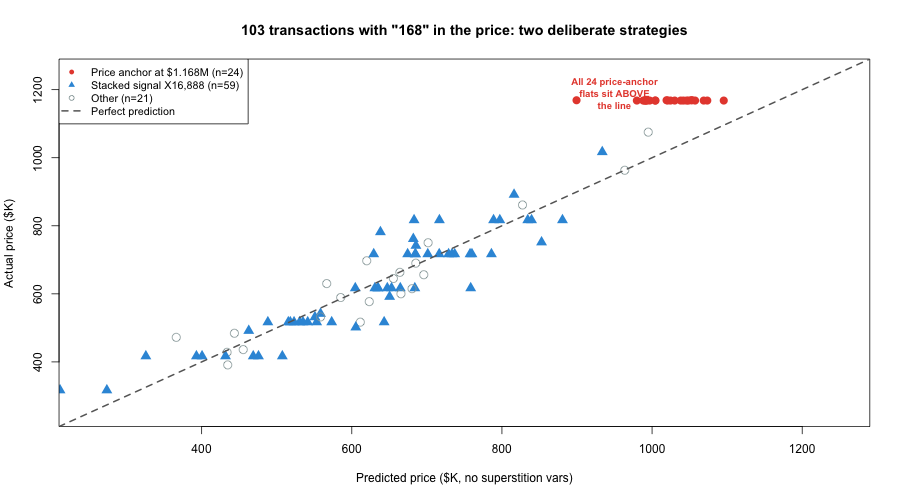

In [12]:
%%R -w 900 -h 500
# All 168 transactions: actual price vs predicted price, coloured by strategy
df_168 <- df[df$price_has_168 == 1, ]

df_168$type_168 <- ifelse(
    df_168$resale_price >= 1168000 & df_168$resale_price <= 1168888,
    'Price anchor ($1.168M)',
    ifelse(df_168$resale_price %% 1000 == 888 | df_168$resale_price %% 1000 == 688,
        'Stacked signal (X16,888)',
        'Other 168'))

df_168$pred_base <- predict(model_base, df_168)

# Colour map
cols <- ifelse(df_168$type_168 == 'Price anchor ($1.168M)', '#e74c3c',
        ifelse(df_168$type_168 == 'Stacked signal (X16,888)', '#3498db', '#95a5a6'))
pchs <- ifelse(df_168$type_168 == 'Price anchor ($1.168M)', 16,
         ifelse(df_168$type_168 == 'Stacked signal (X16,888)', 17, 1))

plot(df_168$pred_base / 1000, df_168$resale_price / 1000,
     col = cols, pch = pchs, cex = 1.5,
     xlab = 'Predicted price ($K, no superstition vars)',
     ylab = 'Actual price ($K)',
     main = '103 transactions with "168" in the price: two deliberate strategies',
     xlim = c(250, 1250), ylim = c(250, 1250))
abline(0, 1, col = 'grey40', lwd = 2, lty = 2)

legend('topleft',
    c(sprintf('Price anchor at $1.168M (n=%d)', sum(df_168$type_168 == 'Price anchor ($1.168M)')),
      sprintf('Stacked signal X16,888 (n=%d)', sum(df_168$type_168 == 'Stacked signal (X16,888)')),
      sprintf('Other (n=%d)', sum(df_168$type_168 == 'Other 168')),
      'Perfect prediction'),
    col = c('#e74c3c', '#3498db', '#95a5a6', 'grey40'),
    pch = c(16, 17, 1, NA), lty = c(NA, NA, NA, 2), lwd = c(NA, NA, NA, 2),
    cex = 0.9, bg = 'white')

text(950, 1190, 'All 24 price-anchor\nflats sit ABOVE\nthe line',
     col = '#e74c3c', cex = 0.8, font = 2)

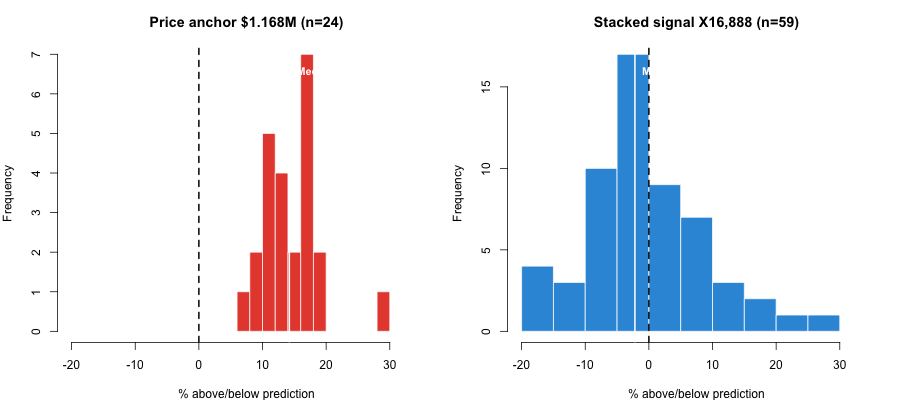

In [13]:
%%R -w 900 -h 400
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Price anchor: histogram of % gap
anchor <- df_168[df_168$type_168 == 'Price anchor ($1.168M)', ]
anchor$gap_pct <- (anchor$resale_price - anchor$pred_base) / anchor$pred_base * 100

hist(anchor$gap_pct, breaks = 15, col = '#e74c3c', border = 'white',
     main = sprintf('Price anchor $1.168M (n=%d)', nrow(anchor)),
     xlab = '% above/below prediction',
     xlim = c(-20, 35))
abline(v = 0, col = 'black', lwd = 2, lty = 2)
abline(v = median(anchor$gap_pct), col = 'white', lwd = 2)
text(median(anchor$gap_pct), par('usr')[4] * 0.9,
     sprintf('Median: +%.1f%%', median(anchor$gap_pct)),
     col = 'white', cex = 0.9, font = 2, pos = 4)

# Stacked signal: histogram of % gap
stacked <- df_168[df_168$type_168 == 'Stacked signal (X16,888)', ]
stacked$gap_pct <- (stacked$resale_price - stacked$pred_base) / stacked$pred_base * 100

hist(stacked$gap_pct, breaks = 15, col = '#3498db', border = 'white',
     main = sprintf('Stacked signal X16,888 (n=%d)', nrow(stacked)),
     xlab = '% above/below prediction',
     xlim = c(-20, 35))
abline(v = 0, col = 'black', lwd = 2, lty = 2)
abline(v = median(stacked$gap_pct), col = 'white', lwd = 2)
text(median(stacked$gap_pct), par('usr')[4] * 0.9,
     sprintf('Median: %+.1f%%', median(stacked$gap_pct)),
     col = 'white', cex = 0.9, font = 2, pos = 4)

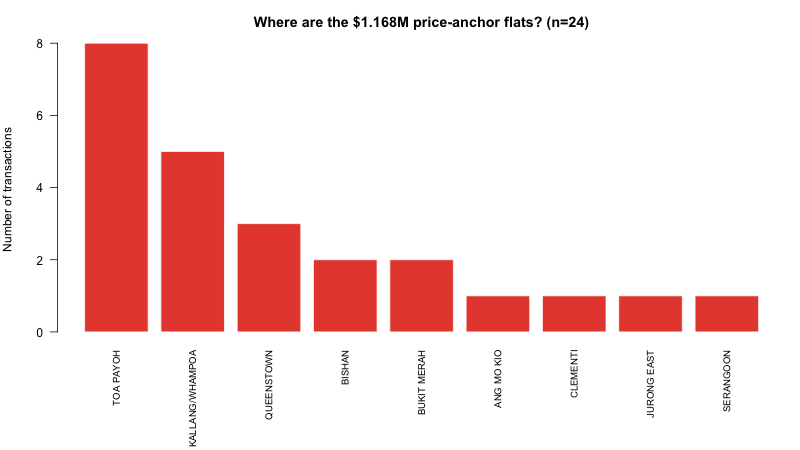

In [14]:
%%R -w 800 -h 450
# Where are the price-anchor flats? Bar chart by town
anchor_plot <- df_168[df_168$type_168 == 'Price anchor ($1.168M)', ]
town_counts <- table(anchor_plot$town)
town_counts <- sort(town_counts, decreasing = TRUE)

par(mar = c(8, 4, 3, 1))
barplot(town_counts, las = 2, col = '#e74c3c', border = 'white',
        main = sprintf('Where are the $1.168M price-anchor flats? (n=%d)', nrow(anchor_plot)),
        ylab = 'Number of transactions',
        cex.names = 0.8)

In [15]:
%%R
# Final comparison table
model12 <- lm(resale_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              month_factor,
            data = df)

df$pred12 <- predict(model12, df)
df$resid12 <- df$resale_price - df$pred12
df$resid12_pct <- round(df$resid12 / df$pred12 * 100, 1)

groups <- list(
    list('All flats (baseline)', df),
    list('No trailing 8s', df[df$num_eights_tail == 0, ]),
    list('1-2 trailing 8s', df[df$num_eights_tail >= 1 & df$num_eights_tail <= 2, ]),
    list('3+ trailing 8s', df[df$num_eights_tail >= 3, ]),
    list('Stacked signal (X16,888)', df[df$price_has_168 == 1 &
        df$resale_price < 1168000, ]),
    list('Price anchor ($1.168M)', df[df$price_has_168 == 1 &
        df$resale_price >= 1168000 & df$resale_price <= 1168888, ])
)

cat(sprintf('%-30s %7s %12s %12s %10s %8s\n',
    'Group', 'N', 'Avg price', 'Avg pred', 'Avg gap', '% above'))
cat(paste(rep('=', 82), collapse = ''), '\n')

for (g in groups) {
    label <- g[[1]]
    subset <- g[[2]]
    avg_gap <- mean(subset$resid12_pct)
    pct_above <- mean(subset$resid12 > 0) * 100
    cat(sprintf('%-30s %7s $%10s $%10s %+8.1f%% %7.0f%%\n',
        label,
        format(nrow(subset), big.mark = ','),
        format(round(mean(subset$resale_price)), big.mark = ','),
        format(round(mean(subset$pred12)), big.mark = ','),
        avg_gap,
        pct_above))
}

Group                                N    Avg price     Avg pred    Avg gap  % above


All flats (baseline)            51,740 $   642,727 $   642,727     +0.3%      48%


No trailing 8s                  39,640 $   636,270 $   636,502     +0.3%      48%


1-2 trailing 8s                  7,610 $   655,487 $   653,674     +0.5%      50%


3+ trailing 8s                   4,490 $   678,113 $   679,133     -0.2%      47%


Stacked signal (X16,888)            80 $   622,357 $   623,201     +0.2%      44%


Price anchor ($1.168M)              24 $ 1,168,192 $ 1,077,771     +8.6%     100%


## PropertyGuru listings: the agent pricing strategy

The regression analyses transactions — completed sales. PropertyGuru shows the other side: what agents are *asking* for. If the 168 price anchor is a deliberate strategy, we should see it in listing prices too — and we might see agents pricing *above* 168 to build in bargaining room (e.g. listing at $1,178,888 so the buyer can "negotiate down" to $1,168,000).

In [16]:
%%R
# Load PropertyGuru HDB listings
pg <- read_csv('data/propertyguru_hdb_listings.csv', show_col_types = FALSE)
pg <- pg[!is.na(pg$price) & pg$price > 100000, ]

cat(sprintf('PropertyGuru HDB listings: %s\n', format(nrow(pg), big.mark = ',')))
cat(sprintf('Price range: $%s to $%s\n\n',
    format(min(pg$price), big.mark = ','),
    format(max(pg$price), big.mark = ',')))

# Derive superstition vars
pg$price_str <- as.character(as.integer(pg$price))
pg$last4 <- substr(pg$price_str, nchar(pg$price_str)-3, nchar(pg$price_str))
pg$num_eights_tail <- nchar(gsub('[^8]', '', pg$last4))
pg$has_168 <- grepl('168', pg$price_str)
pg$ends_888 <- grepl('888$', pg$price_str)
pg$ends_78888 <- grepl('78888$', pg$price_str)

cat('=== Auspicious patterns: listings vs transactions ===\n\n')
cat(sprintf('%-30s %14s %14s\n', '', 'PG listings', 'Transactions'))
cat(paste(rep('-', 60), collapse = ''), '\n')
cat(sprintf('%-30s %13.1f%% %13.1f%%\n', 'Has trailing 8s',
    mean(pg$num_eights_tail > 0) * 100,
    mean(df$num_eights_tail > 0) * 100))
cat(sprintf('%-30s %13.1f%% %13.1f%%\n', 'Ends in 888',
    mean(pg$ends_888) * 100, 8.7))
cat(sprintf('%-30s %13.1f%% %13.1f%%\n', 'Contains 168',
    mean(pg$has_168) * 100, mean(df$price_has_168) * 100))
cat(sprintf('%-30s %13d %13d\n', 'At $1,168,000-$1,168,888',
    sum(pg$price >= 1168000 & pg$price <= 1168888),
    sum(df$resale_price >= 1168000 & df$resale_price <= 1168888)))

PropertyGuru HDB listings: 13,338


Price range: $2e+05 to $9,350,000



=== Auspicious patterns: listings vs transactions ===



                                  PG listings   Transactions


------------------------------------------------------------

Has trailing 8s                         27.7%          23.4%


Ends in 888                              6.9%           8.7%


Contains 168                             0.1%           0.2%


At $1,168,000-$1,168,888                   5            24


In addition: Warning message:
One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 


In [17]:
%%R
# The negotiation corridor: $1.16M to $1.19M
# Agents list ABOVE 168 to build in bargaining room

corridor <- pg[pg$price >= 1160000 & pg$price <= 1190000, ]
corridor <- corridor[order(corridor$price), ]

cat('=== PropertyGuru listings: the $1.16M-$1.19M negotiation corridor ===\n\n')

# Group by price tiers
tiers <- list(
    list('$1,160,000 (round)', 1160000, 1160000),
    list('$1,168,000-$1,168,888 (168 anchor)', 1168000, 1168888),
    list('$1,170,000 (round)', 1170000, 1170000),
    list('$1,175,000-$1,176,888 (mid-range)', 1174000, 1176888),
    list('$1,178,888 (bargaining cushion)', 1178888, 1178888),
    list('$1,180,000 (round)', 1180000, 1180000),
    list('$1,188,000-$1,188,888 (above anchor)', 1188000, 1188888),
    list('$1,190,000 (round)', 1190000, 1190000)
)

cat(sprintf('%-40s %8s\n', 'Price tier', 'Listings'))
cat(paste(rep('-', 50), collapse = ''), '\n')

for (t in tiers) {
    label <- t[[1]]
    lo <- t[[2]]
    hi <- t[[3]]
    n <- sum(corridor$price >= lo & corridor$price <= hi)
    cat(sprintf('%-40s %8d\n', label, n))
}

cat(sprintf('\n%-40s %8d\n', 'TOTAL in corridor', nrow(corridor)))

=== PropertyGuru listings: the $1.16M-$1.19M negotiation corridor ===



Price tier                               Listings


--------------------------------------------------

$1,160,000 (round)                              9


$1,168,000-$1,168,888 (168 anchor)              5


...

$1,178,888 (bargaining cushion)                 1


$1,180,000 (round)                             39


$1,188,000-$1,188,888 (above anchor)           26


$1,190,000 (round)                             13



TOTAL in corridor                             104


In [18]:
%%R
# Same corridor in TRANSACTIONS — do listing prices above 168 negotiate down to 168?
txn_corridor <- df[df$resale_price >= 1160000 & df$resale_price <= 1190000, ]
txn_corridor <- txn_corridor[order(txn_corridor$resale_price), ]

cat('=== Transactions in the $1.16M-$1.19M corridor ===\n\n')

txn_tiers <- list(
    list('$1,160,000-$1,167,999', 1160000, 1167999),
    list('$1,168,000-$1,168,888 (168 anchor)', 1168000, 1168888),
    list('$1,169,000-$1,174,999', 1169000, 1174999),
    list('$1,175,000-$1,176,888', 1175000, 1176888),
    list('$1,177,000-$1,178,888 (bargain cushion)', 1177000, 1178888),
    list('$1,179,000-$1,188,888', 1179000, 1188888),
    list('$1,189,000-$1,190,000', 1189000, 1190000)
)

cat(sprintf('%-45s %8s\n', 'Price tier', 'Txns'))
cat(paste(rep('-', 55), collapse = ''), '\n')

for (t in txn_tiers) {
    label <- t[[1]]
    lo <- t[[2]]
    hi <- t[[3]]
    n <- sum(txn_corridor$resale_price >= lo & txn_corridor$resale_price <= hi)
    cat(sprintf('%-45s %8d\n', label, n))
}

cat(sprintf('\n%-45s %8d\n', 'TOTAL in corridor', nrow(txn_corridor)))

# The $X78,888 pattern across all price levels (listing vs transaction)
cat('\n\n=== The $X78,888 bargaining cushion across ALL price levels ===\n')
cat('(Prices ending in 78,888 — ~$10K above each X68,888 tier)\n\n')

pg$ends_78888 <- grepl('78888$', pg$price_str)
df$price_str <- as.character(as.integer(df$resale_price))
df$ends_78888 <- grepl('78888$', df$price_str)

cat(sprintf('%-30s %14s %14s\n', '', 'PG listings', 'Transactions'))
cat(paste(rep('-', 60), collapse = ''), '\n')
cat(sprintf('%-30s %14d %14d\n', 'Prices ending in X78,888',
    sum(pg$ends_78888), sum(df$ends_78888)))
cat(sprintf('%-30s %13.1f%% %13.1f%%\n', '% of total',
    mean(pg$ends_78888) * 100, mean(df$ends_78888) * 100))

# List them
cat('\nTransaction prices ending in X78,888:\n')
x78_txn <- df[df$ends_78888 == TRUE, ]
x78_txn <- x78_txn[order(-x78_txn$resale_price), ]

cat(sprintf('%-12s %-6s %-22s %-10s %12s\n',
    'Month', 'Block', 'Street', 'Type', 'Price'))
cat(paste(rep('-', 66), collapse = ''), '\n')
for (i in 1:min(nrow(x78_txn), 20)) {
    r <- x78_txn[i, ]
    cat(sprintf('%-12s %-6s %-22s %-10s $%10s\n',
        format(r$month, '%Y-%m'),
        r$block,
        substr(r$street_name, 1, 22),
        r$flat_type,
        format(round(r$resale_price), big.mark = ',')))
}
if (nrow(x78_txn) > 20) cat(sprintf('\n... and %d more\n', nrow(x78_txn) - 20))

=== Transactions in the $1.16M-$1.19M corridor ===



Price tier                                        Txns


-------------------------------------------------------

$1,160,000-$1,167,999                               41


$1,168,000-$1,168,888 (168 anchor)                  24


...

2025-07      605A   TAMPINES ST 61         5 ROOM     $   878,888


2026-03      360    WOODLANDS AVE 5        EXECUTIVE  $   878,888


2024-06      226C   SUMANG LANE            5 ROOM     $   778,888


2024-08      259C   PUNGGOL FIELD          5 ROOM     $   778,888



... and 80 more


In [19]:
%%R
# The $1,168,000 listings on PropertyGuru — detail view
cat('=== Active $1,168,000 listings on PropertyGuru ===\n\n')

pg_1168 <- pg[pg$price >= 1168000 & pg$price <= 1168888, ]
pg_1168 <- pg_1168[order(pg_1168$price), ]

for (i in 1:nrow(pg_1168)) {
    r <- pg_1168[i, ]
    cat(sprintf('Listing %d:\n', i))
    cat(sprintf('  Address:  %s\n', ifelse(is.na(r$full_address), 'NA', r$full_address)))
    cat(sprintf('  Type:     %s\n', r$hdb_type_code))
    cat(sprintf('  Price:    $%s\n', format(round(r$price), big.mark = ',')))
    cat(sprintf('  Floor:    %s\n', ifelse(is.na(r$floor_level), '?', r$floor_level)))
    cat(sprintf('  Area:     %.0f sqft (%.0f sqm)\n',
        ifelse(is.na(r$floor_area_sqft), 0, r$floor_area_sqft),
        ifelse(is.na(r$floor_area_sqft), 0, r$floor_area_sqft / 10.764)))
    cat(sprintf('  Agent:    %s (%s)\n', r$agent_name, r$agency_name))
    cat(sprintf('  Listed:   %s\n', r$listed_date))
    cat(sprintf('  URL:      %s\n\n', r$listing_url))
}

# Also show listings at $1,178,888 (the bargaining cushion)
cat('\n=== Listings at $1,178,888 (bargaining cushion above 168) ===\n\n')
pg_1178 <- pg[pg$price == 1178888, ]
if (nrow(pg_1178) > 0) {
    for (i in 1:nrow(pg_1178)) {
        r <- pg_1178[i, ]
        cat(sprintf('  %s — %s, $%s, %s (%s)\n',
            ifelse(is.na(r$full_address), 'NA', r$full_address),
            r$hdb_type_code,
            format(round(r$price), big.mark = ','),
            r$agent_name, r$agency_name))
    }
} else {
    cat('  None currently listed.\n')
}

# And $1,188,888
cat('\n=== Listings at $1,188,888 ===\n\n')
pg_1188 <- pg[pg$price == 1188888, ]
if (nrow(pg_1188) > 0) {
    for (i in 1:nrow(pg_1188)) {
        r <- pg_1188[i, ]
        cat(sprintf('  %s — %s, $%s, %s (%s)\n',
            ifelse(is.na(r$full_address), 'NA', r$full_address),
            r$hdb_type_code,
            format(round(r$price), big.mark = ','),
            r$agent_name, r$agency_name))
    }
} else {
    cat('  None currently listed.\n')
}

=== Active $1,168,000 listings on PropertyGuru ===



Listing 1:


  Address:  NA


  Type:     EM


  Price:    $1,168,000


...

  206 Clementi Avenue 6 — EA, $1,188,888, Alize Ng (NA)


  87 Dawson Road — 4PA, $1,188,888, Carrie Zhang (PROPNEX REALTY PTE. LTD.)


  104A Bidadari Park Drive — 4A, $1,188,888, Jason Ng (PROPNEX REALTY PTE. LTD.)


  95A Henderson Road — 4A, $1,188,888, Robin Wong (KW SINGAPORE REAL ESTATE PTE. LTD.)


  32 Margaret Drive — 4PA, $1,188,888, Angeline Koh (PROPNEX REALTY PTE. LTD.)
